# Regressão Linear - Projeto

Parabéns! Você conseguiu um contrato de trabalho com uma empresa de comércio eletrônico com sede na cidade de Nova York que vende roupas online, mas também tem sessões de consultoria em estilo e vestuário na loja. Os clientes entram na loja, têm sessões / reuniões com um estilista pessoal, então podem ir para casa e encomendarem em um aplicativo mobile ou site para a roupa que desejam.

A empresa está tentando decidir se deve concentrar seus esforços em aplicativos móveis ou em seu site. Eles contrataram você para ajudá-los a descobrir isso! Vamos começar!

Basta seguir as etapas abaixo para analisar os dados do cliente (é falso, não se preocupe, eu não lhe dei números reais de cartões de crédito ou e-mails).

## Imports

In [302]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Obter dados

Trabalharemos com o arquivo csv do Ecommerce Customers da empresa. Possui informações do cliente, como Email, Endereço e sua cor Avatar. Em seguida, ele também possui colunas de valores numéricos:.

* Avg. Session Length: Tempo médio das sessões de consultoria de estilo na loja.
* Time on App: tempo médio gasto no app em minutos.
* Time on Website: tempo médio gasto no site em minutos.
* Lenght of Membership: Há quantos anos o cliente é membro.

** Leia no arquivo csv do Ecommerce Customers como um DataFrame chamado clientes. **

In [303]:
clientes = pd.read_csv(r"C:\Users\FernandoSantos\projetos\github_pessoal\Linear_Regression_Project\ecommerce-customers.csv")

**Verifique o cabeçalho dos clientes e confira os seus métodos info () e describe().**

In [304]:
clientes.head(5)

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [305]:
clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


In [306]:
clientes.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


### EDA

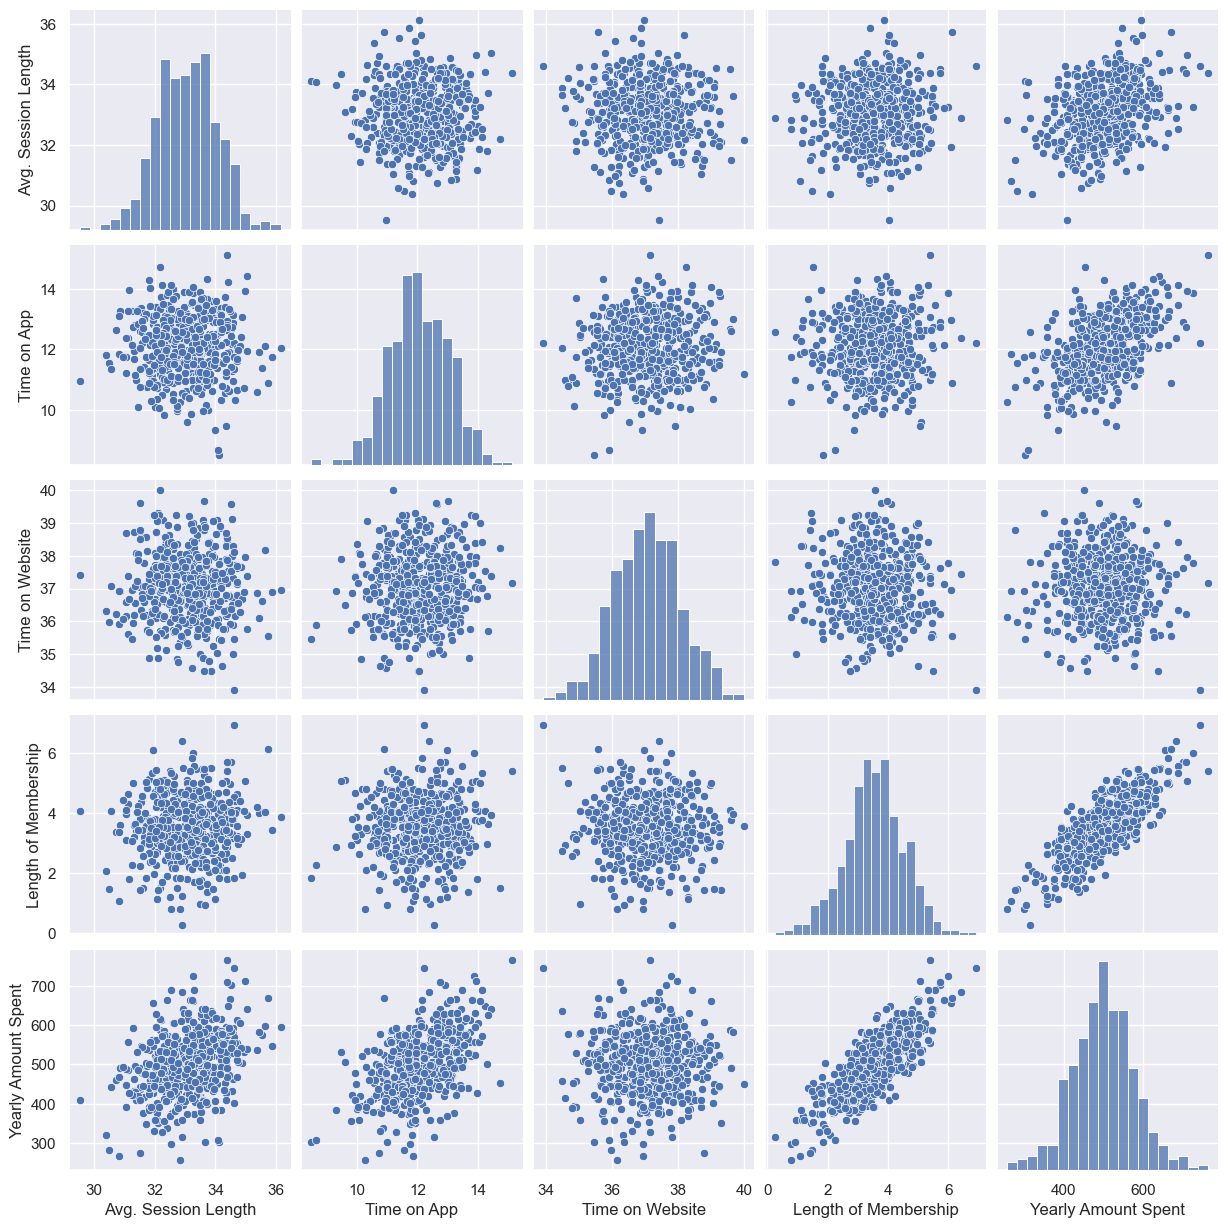

In [307]:
sns.pairplot(clientes[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']]);

- O tempo gasto no App parece ter correlação linear com o valor gasto!
- O tempo gasto no site não parece ter correlação com o valor gasto 
- Clientes com mais tempo de casa parecem gastar mais por ano.
- Não parece haver relação entre o "tempo de casa" e o quanto os clientes gastam de tempo no App ou Website.
- Não parece haver nenhuma correlação entre o tempo gasto no App e Website.

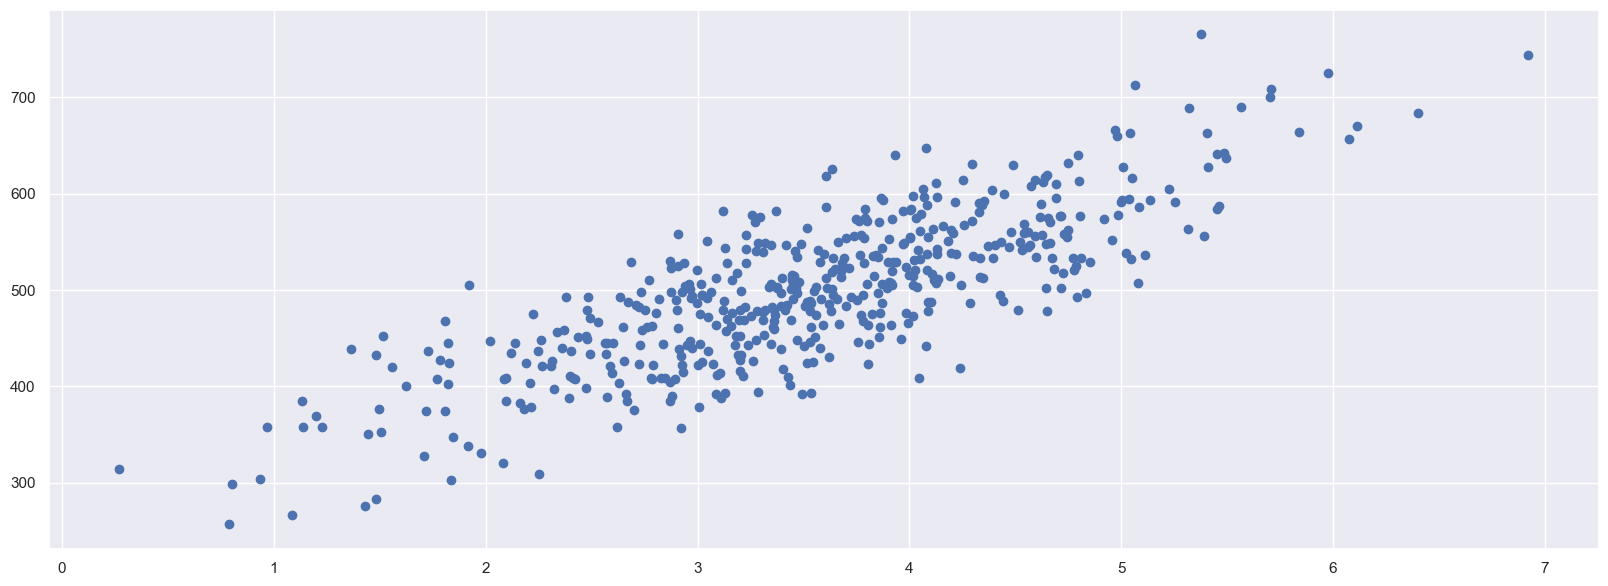

In [308]:
fig, ax = plt.subplots(figsize=(20, 7))
plt.scatter(clientes['Length of Membership'], clientes['Yearly Amount Spent']);

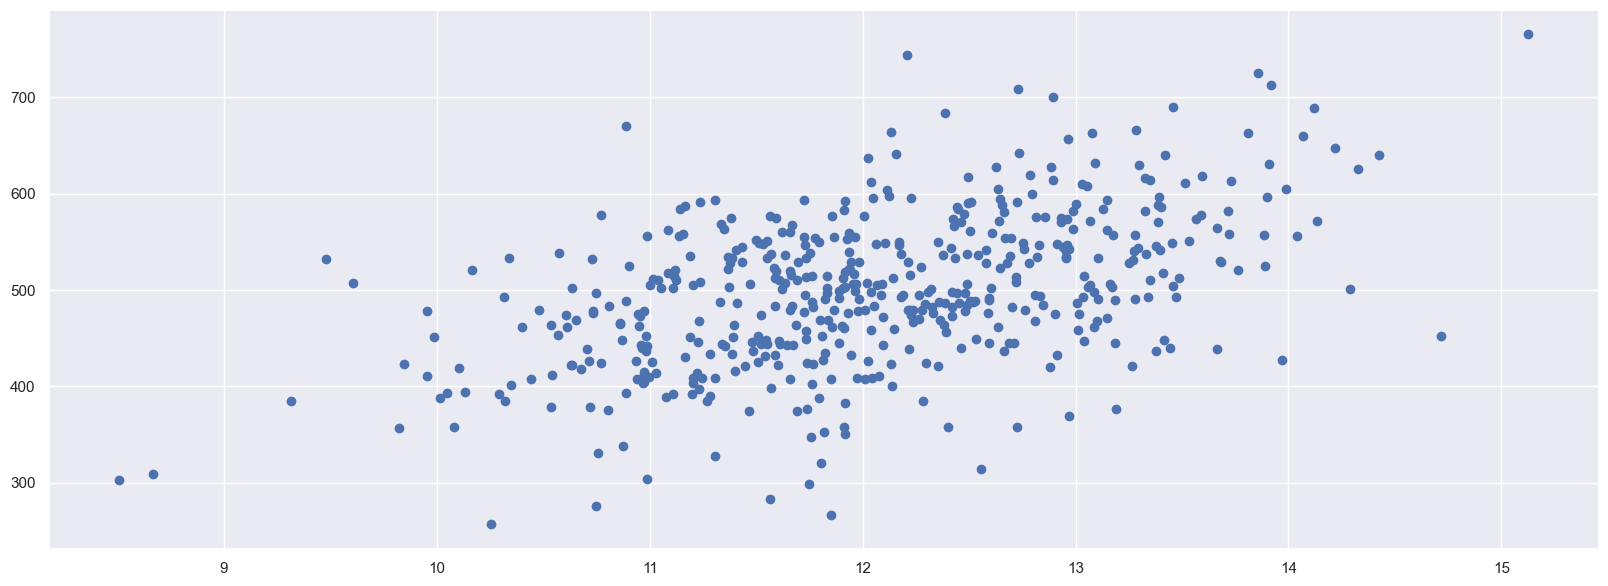

In [309]:
fig, ax = plt.subplots(figsize=(20, 7))
plt.scatter(clientes['Time on App'], clientes['Yearly Amount Spent']);

<Axes: >

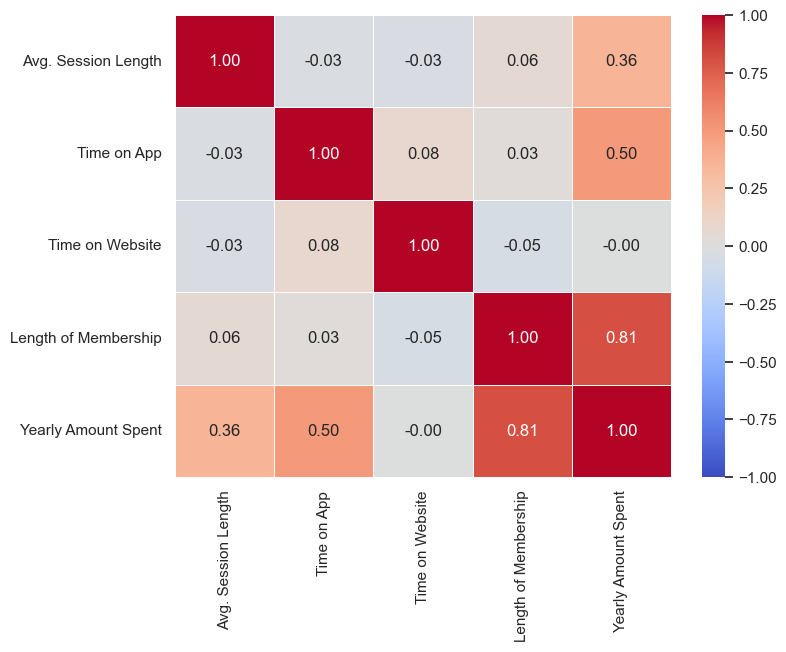

In [310]:
correlation_matrix = clientes[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']].corr(method='pearson')

plt.figure(figsize=(8, 6)) # Optional: Adjust figure size
sns.heatmap(
    correlation_matrix,
    annot=True,         # Annotate the heatmap with the correlation values
    cmap='coolwarm',    # Use a diverging colormap, e.g., 'coolwarm', 'RdBu_r'
    fmt=".2f",          # Format the annotations to two decimal places
    linewidths=0.5,     # Add lines between cells
    vmin=-1,            # Ensure the color bar goes from -1 to 1
    vmax=1,
    center=0            # Center the colormap at 0
)

Como podemos ver a maior correlação com o valor gasto é o tempo de associação, seguido do tempo gasto no App. O tempo gasto na sessão também parece ter um reflexo positivo com o valor gasto anualmente.Vamos analisar a significancia das correlações.

In [311]:
from scipy.stats import pearsonr


def calculate_pvalues(df):
    pvalues = pd.DataFrame(index=df.columns, columns=df.columns, dtype=float)

    for r in df.columns:
        for c in df.columns:
            if r == c:
                pvalues.loc[r, c] = np.nan
                continue

            tmp = df[[r, c]].dropna()

            if len(tmp) >= 2 and tmp[r].nunique() > 1 and tmp[c].nunique() > 1:
                pvalues.loc[r, c] = pearsonr(tmp[r], tmp[c]).pvalue
            else:
                pvalues.loc[r, c] = np.nan

    return pvalues.round(4)


pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)

p_values_df = calculate_pvalues(clientes[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']])
print(p_values_df)

                      Avg. Session Length  Time on App  Time on Website  \
Avg. Session Length                   NaN       0.5348           0.4350   
Time on App                        0.5348          NaN           0.0657   
Time on Website                    0.4350       0.0657              NaN   
Length of Membership               0.1786       0.5156           0.2883   
Yearly Amount Spent                0.0000       0.0000           0.9530   

                      Length of Membership  Yearly Amount Spent  
Avg. Session Length                 0.1786                0.000  
Time on App                         0.5156                0.000  
Time on Website                     0.2883                0.953  
Length of Membership                   NaN                0.000  
Yearly Amount Spent                 0.0000                  NaN  


Podemos observar que as unicas correlações significativas (com a variável "Yearly Amount Spent") foram: "Length of Membership", "Avg. Session Length" e "Time on App". 
Confirmando nossas suspeitas.

Apenas com a EDA já podemos concluir que os esforços devem ser em melhorar a experiência do App, que está diretamente relacionado a maior receita anual.

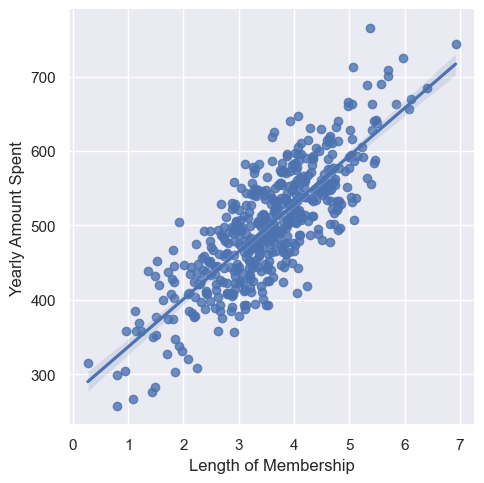

In [312]:
sns.lmplot(x='Length of Membership', y='Yearly Amount Spent', data=clientes);

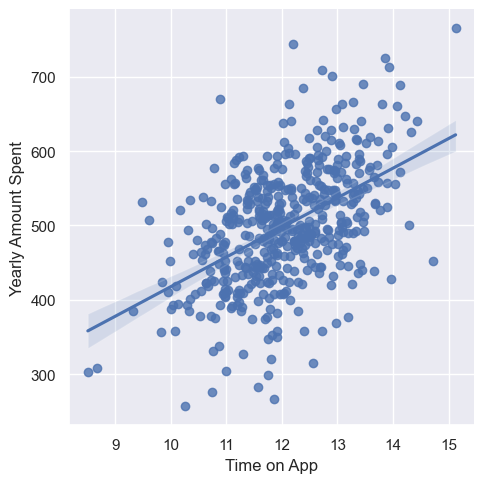

In [313]:
sns.lmplot(x='Time on App', y='Yearly Amount Spent', data=clientes);

## Treinando e testando os dados

Agora que exploramos um pouco os dados, vamos avançar e dividir os dados em conjuntos de treinamento e teste.

In [314]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

x = clientes[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]
y = clientes[['Yearly Amount Spent']]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=101)

## Treinando o modelo

In [315]:
lm = LinearRegression()
lm.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [316]:
lm.coef_

array([[25.98154972, 38.59015875,  0.19040528, 61.27909654]])

## Previsão de dados de teste

In [317]:
y_pred = lm.predict(x_test)

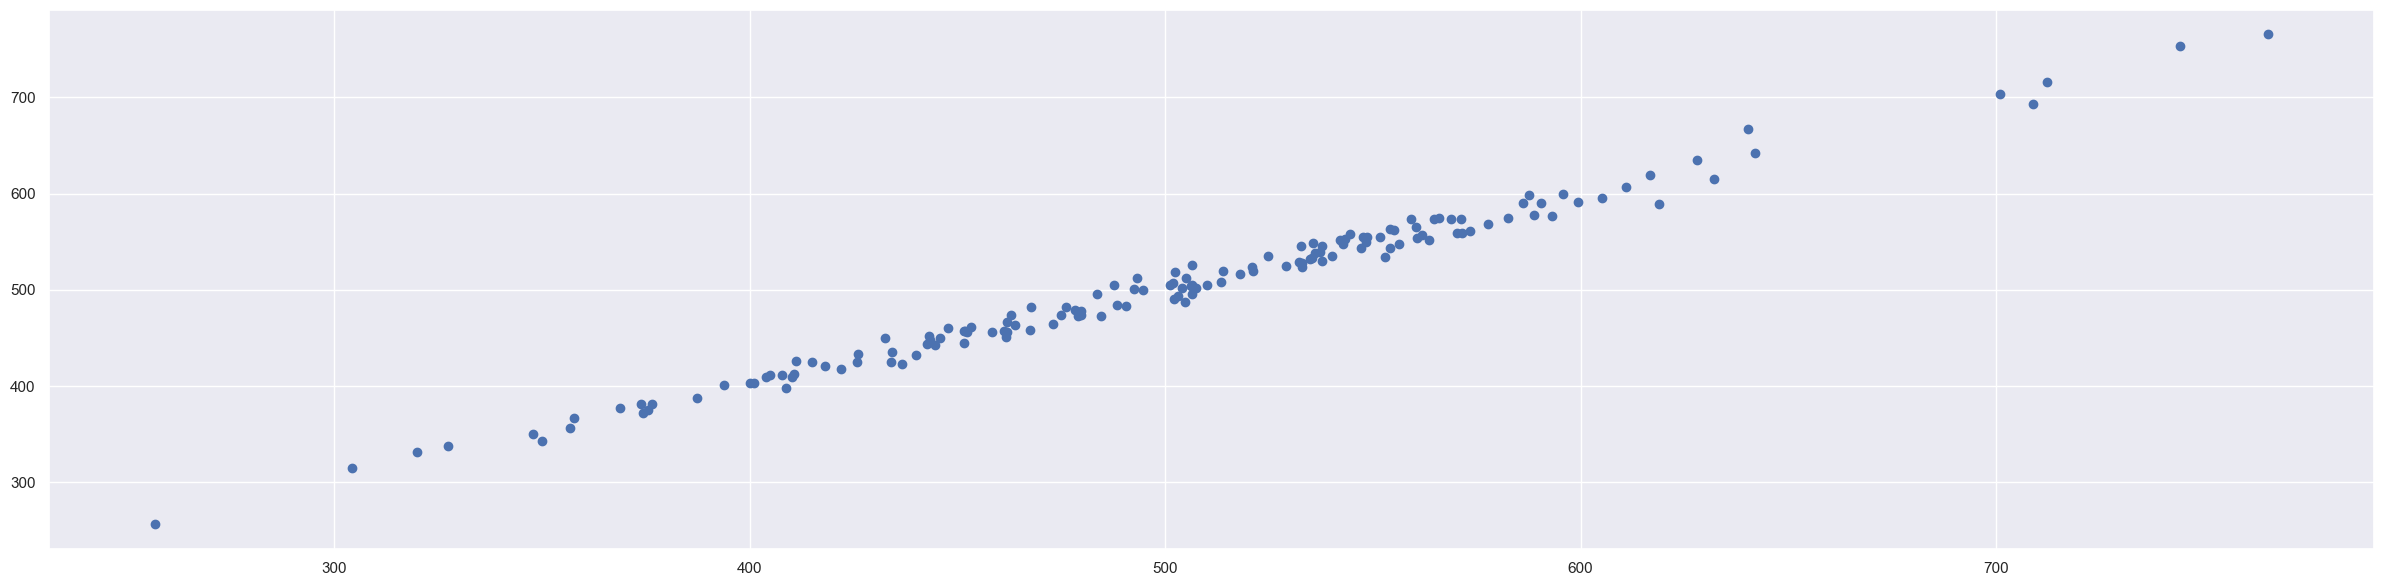

In [318]:
plt.scatter(y_test, y_pred);

## Avaliando o Modelo

In [319]:
residuals = y_test - y_pred

MAE = np.abs(residuals).mean()
MSE = (residuals**2).mean()
RMSE = np.sqrt(MSE)

print('MAE:', MAE)
print('MSE:', MSE)
print('RMSE:', RMSE)

MAE: Yearly Amount Spent    7.228149
dtype: float64
MSE: Yearly Amount Spent    79.813052
dtype: float64
RMSE: Yearly Amount Spent    8.933815
dtype: float64


Poderiamos ter utilizado o modulo 'metrics' do pacote sklearn

In [320]:
from sklearn import metrics

print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 7.228148653430811
MSE: 79.81305165097385
RMSE: 8.9338150669786


## Resíduos

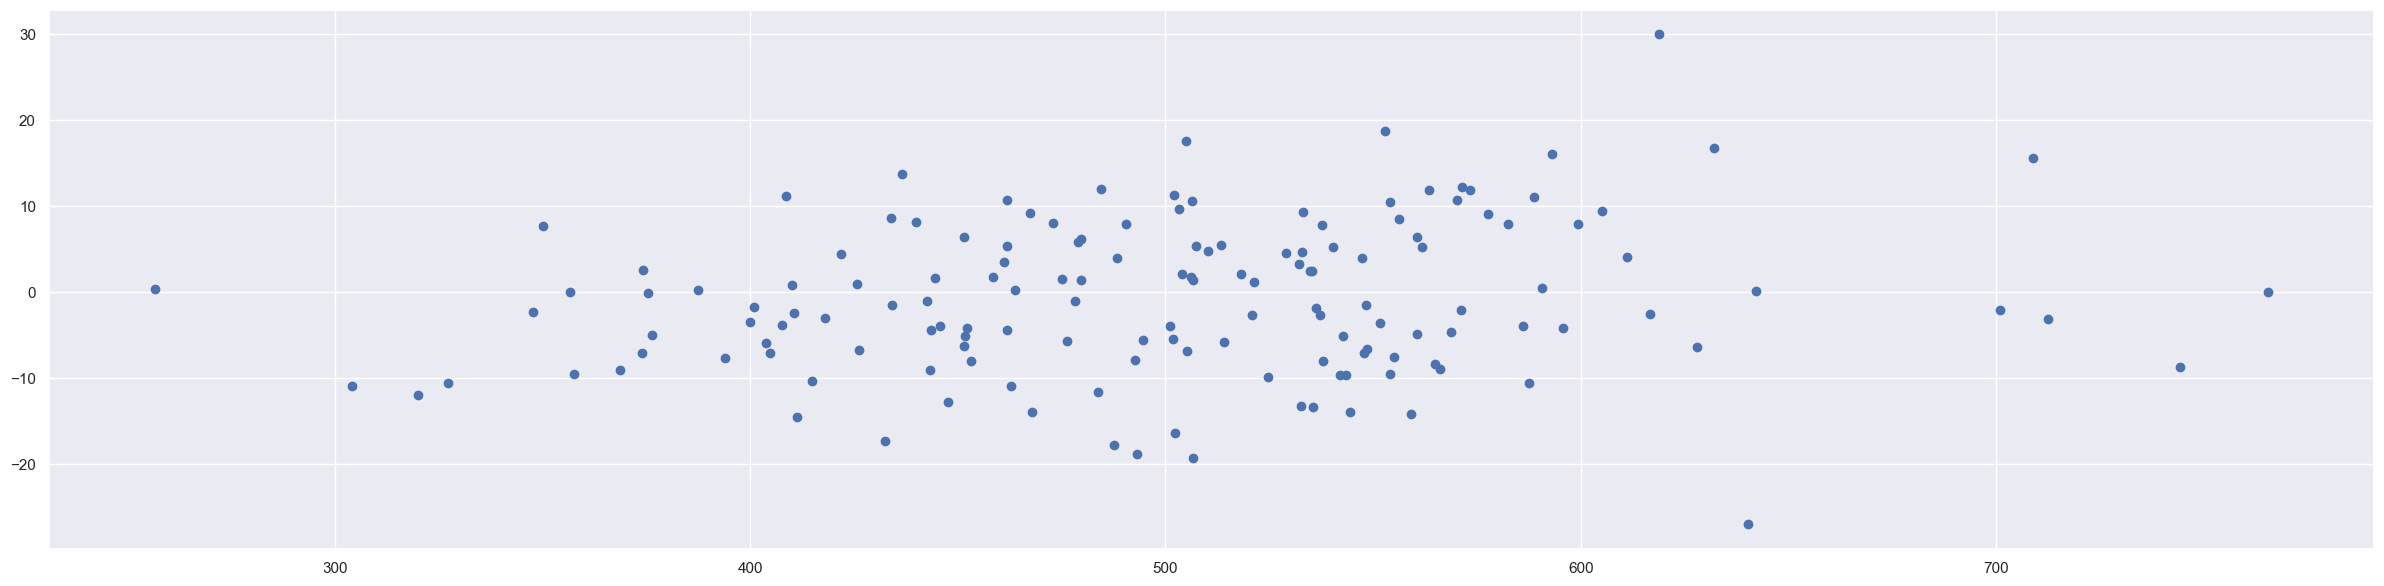

In [321]:
plt.scatter(y_test, residuals);

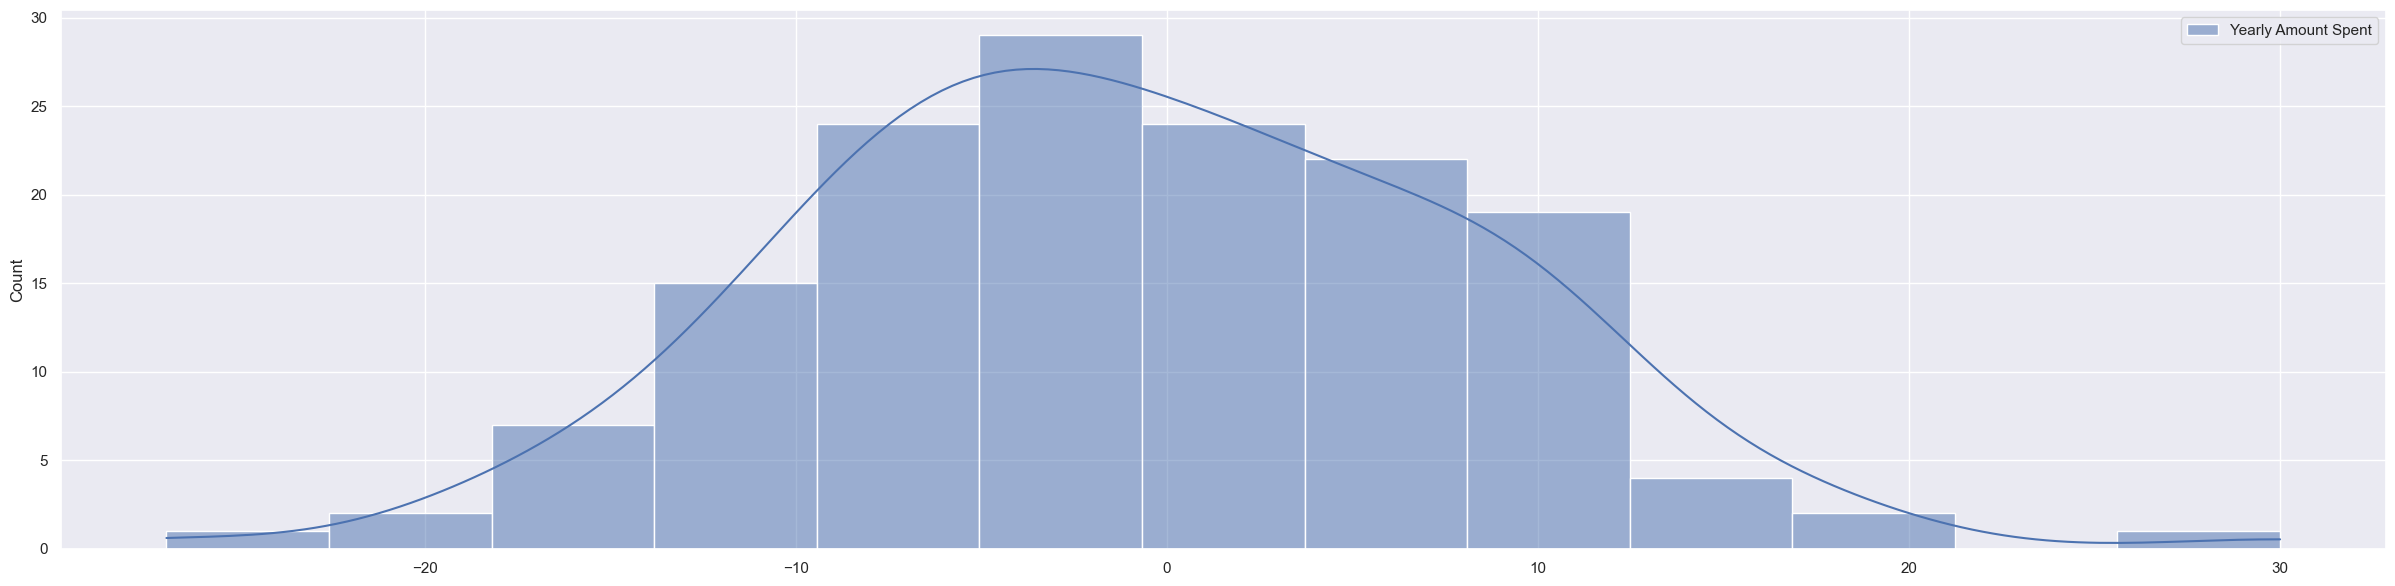

In [322]:
sns.histplot(residuals, kde=True);

## Conclusão

In [323]:
coefs = pd.DataFrame(lm.coef_.T, index=x.columns, columns=['Coef'])
coefs

,Coef
Avg. Session Length,25.981550
Time on App,38.590159
Time on Website,0.190405
Length of Membership,61.279097


In [324]:
import statsmodels.api as sm

# adicionar intercept
X_train = sm.add_constant(x_train)

model = sm.OLS(y_train, X_train).fit()

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Yearly Amount Spent   R-squared:                       0.982
Model:                             OLS   Adj. R-squared:                  0.982
Method:                  Least Squares   F-statistic:                     4641.
Date:                 Thu, 19 Feb 2026   Prob (F-statistic):          1.88e-298
Time:                         14:50:14   Log-Likelihood:                -1314.1
No. Observations:                  350   AIC:                             2638.
Df Residuals:                      345   BIC:                             2658.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -

Como podemos observar p-valor do coeficiente de "Time on Website" > 0.05, portanto não significativo se considerarmos alpha = 0.05

Retirando essa variável talvez possamos melhor o modelo, ou ao menos ter um modelo mais parcimonioso.

In [325]:
X = x.drop(columns= 'Time on Website')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)
lm.fit(X_train, y_train)

lm.coef_

array([[25.98759055, 38.60941287, 61.2690456 ]])

In [326]:
y_pred = lm.predict(X_test)

In [327]:
X_train = sm.add_constant(X_train)

model = sm.OLS(y_train, X_train).fit()

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Yearly Amount Spent   R-squared:                       0.982
Model:                             OLS   Adj. R-squared:                  0.982
Method:                  Least Squares   F-statistic:                     6204.
Date:                 Thu, 19 Feb 2026   Prob (F-statistic):          2.32e-300
Time:                         14:50:14   Log-Likelihood:                -1314.2
No. Observations:                  350   AIC:                             2636.
Df Residuals:                      346   BIC:                             2652.
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -

O modelo parece explicar tão bem quanto o modelo original. Vamos concluir com um teste F.

In [328]:
residuals_n = y_test - y_pred

MAE_n =  metrics.mean_absolute_error(y_test, y_pred)
MSE_n =  metrics.mean_squared_error(y_test, y_pred)
RMSE_n = np.sqrt(metrics.mean_squared_error(y_test, y_pred))

print(f'MAE antes: {MAE}, MAE depois: {MAE_n}')
print(f'MSE antes: {MSE}, MSE depois: {MSE_n}')
print(f'RMSE antes: {RMSE}, RMSE depois: {RMSE_n}')

MAE antes: Yearly Amount Spent    7.228149
dtype: float64, MAE depois: 7.236949056091381
MSE antes: Yearly Amount Spent    79.813052
dtype: float64, MSE depois: 80.19544609397619
RMSE antes: Yearly Amount Spent    8.933815
dtype: float64, RMSE depois: 8.955191013818531


In [329]:
from sklearn.model_selection import cross_val_score

scores_full = cross_val_score(lm, x, y.values.ravel(), cv=5, scoring='neg_mean_squared_error')
scores_reduced = cross_val_score(lm, X, y.values.ravel(), cv=5, scoring='neg_mean_squared_error')

np.sqrt(-scores_full.mean()), np.sqrt(-scores_reduced.mean())

(np.float64(10.022849786220402), np.float64(10.022930374554726))

As funções de custo pioraram marginalmente.

In [330]:
# y como Series (não DataFrame 2D)
y_tr = y_train.squeeze()

# FULL
X_full = sm.add_constant(x_train[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']])
m_full = sm.OLS(y_tr, X_full).fit()

# REDUCED (remove Website)
X_red = sm.add_constant(x_train[['Avg. Session Length', 'Time on App', 'Length of Membership']])
m_red = sm.OLS(y_tr, X_red).fit()

F, pval, df_diff = m_full.compare_f_test(m_red)

print("F:", F)
print("p-value:", pval)
print("df_diff:", df_diff)


F: 0.10912879205093234
p-value: 0.74133869532239
df_diff: 1.0


Os resultados indicam que o tempo gasto no website não contribui de forma estatisticamente significativa para explicar o valor anual gasto, quando controlamos pelas demais variáveis. Embora o modelo completo apresente erro ligeiramente menor, essa diferença não é relevante do ponto de vista inferencial.

Portanto, os dados sugerem que o aplicativo é o canal mais fortemente associado ao aumento do gasto anual dos clientes, podendo ser considerado prioridade estratégica para investimentos futuros.

Interpretando os coeficientes estatísticamente significativos:

**Mantendo todos as outras variáveis constantes**, um aumento de 1 unidade na média de tempo de uso está associado a um aumento de 25,98 dólares totais gastos.

**Mantendo todos as outras variáveis constantes**, um aumento de 1 unidade no tempo gasto no App está associado a um aumento de 38,61 dólares totais gastos.

**Mantendo todos as outras variáveis constantes**, um aumento de 1 unidade no tempo de Associação está associado a um aumento de 61,27 dólares em dólares.